# Decision Trees

### ¿Qué es la entropía?

* `Entropía` no es un concepto específico del lenguaje, sino un concepto matemático y estadístico que se puede calcular con Python, especialmente en el contexto de:
  - Teoría de la información (como la entropía de Shannon)
  - Aprendizaje automático (por ejemplo, para construir árboles de decisión)
  - Procesamiento de señales e imágenes
  - Análisis de datos

* ¿Qué es la entropía (en general)?
  - La entropía mide la incertidumbre o el desorden de un sistema.
  - En teoría de la información (entropía de Shannon), mide cuánta información se necesita en promedio para describir una variable aleatoria.
  - 𝑝(𝑥𝑖) es la probabilidad del evento 𝑥𝑖.

$$
H(X) = -\sum_{i=1}^{n} p(x_i) \log_2 p(x_i)
$$

* `Scikit-learn`: al construir árboles de decisión `(DecisionTreeClassifier)`, se usa la entropía como criterio para dividir nodos `(criterion="entropy")`.
* Procesamiento de imágenes: para medir el nivel de detalle o ruido en una imagen.
* Criptografía y análisis de datos: para medir la aleatoriedad de datos.

### ¿Qué son las técnicas de caja negra y cuales la blanca?

* Caja Negra en ML
  - Modelos donde no se entiende claramente cómo se toman las decisiones internas. Solo se ven las entradas y salidas.
  - Alta precisión, pero difícil de explicar.
  - No sabes por qué el modelo predice lo que predice.
  - Riesgo en sistemas críticos (medicina, finanzas, justicia).
  - Redes neuronales profundas (Deep Learning)
  - Random Forest (aunque algo interpretable, puede ser opaco)
  - XGBoost y otros métodos de boosting
* Caja Blanca en ML
  - Modelos donde sí se entiende la lógica interna y es posible explicar fácilmente cómo se llega a una predicción.
  - Más fáciles de interpretar, auditar y justificar.
  - Se pueden visualizar reglas, pesos, coeficientes, etc.
  - Menor complejidad, a veces menor precisión.
  - Regresión lineal o logística.
  - Árboles de decisión simples.
  - K-Nearest Neighbors (fácil de entender conceptualmente)

### Árboles de Desición

* Imaginemos que tenemos un arbol en el que hemos clasificado a las variables de un paciente para determinar si padece o no problemas cardíacos.
* Dentro de los árboles de desición tenemos 2 tipos de nodos, nodos condicionales y finales, es decir en los primeros se establece a que subrama van y en el ultimo el resultado.
* Los árboles son técnicas no paramétricas,es decir no se fijan en la distribución de los datos.
* Vease como en la imagen.
![cardiacos](cardiacos.png)

### Gráfica Dispersión: Edad y Colesterol

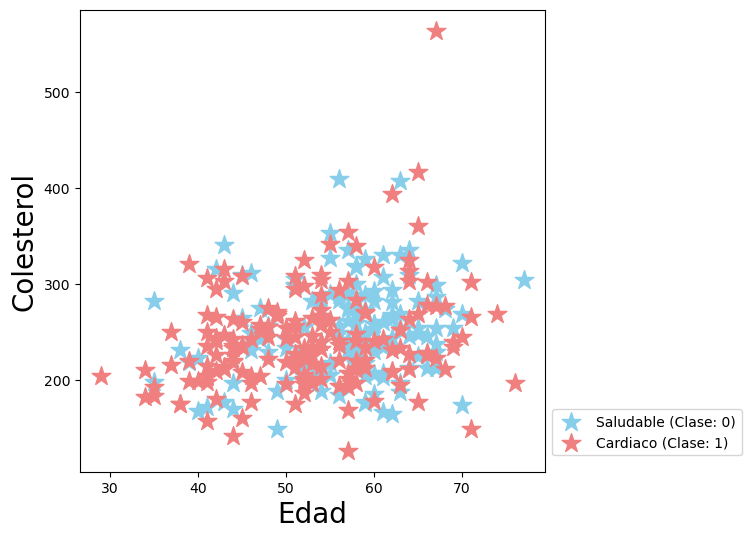

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Sacamos todos los datos de los pacientes
pacientes = pd.read_csv("pacientes.csv")

# Sacamos todos datos de ambos tipos depacientes
saludables = pacientes[pacientes["problema_cardiaco"]==0]
cardiacos = pacientes[pacientes["problema_cardiaco"]==1]

plt.figure(figsize=(6,6))
plt.xlabel("Edad", fontsize=20.0)
plt.ylabel("Colesterol", fontsize=20.0)

# Diagramas de dispersión
plt.scatter(
    saludables["edad"],
    saludables["colesterol"],
    label="Saludable (Clase: 0)",
    marker="*",
    c="skyblue",
    s=200
)

plt.scatter(
    cardiacos["edad"],
    cardiacos["colesterol"],
    label="Cardiaco (Clase: 1)",
    marker="*",
    c="lightcoral",
    s=200
)

plt.legend(bbox_to_anchor=(1,0.15))
plt.show()

### Entropía

* Promedio de información almacenada en una variable aleatoria.
* `log(8,2)`: el logaritmo es practicamente cuantas veces necesitas multiplicar el 2 por si mismo para que te de 8.
* Las librerías de `sklearn` ya incluyen la entropía.
* Esto de los logaritmos también nos ayuda a saber cuantos bits necesitamos para poder alamcenar la información.
* Es decir para representar el '4' en binarios, sería `log(4,2)=2 + 1 = 3`,  es decir ocupariamos 3 bits para representar el 4 en binario, por eso el detalle del '2' en el log. (4 = 100).
* Lo que pasa en el caso de la moneda perfecta, es que existe un caos incontrolable, es decir no hay como preferencia, mientras en el otro es más controlable ya que es más probable que caiga de algun lado.
* Esto en la vida real se puede plantear así, imagenemos que tenemos una serie de datos para entrenar un modelo que asigne o clasique si una persona aplica o no para un crédito hipotecario, el detalle es todos los datos son de los hombres, por lo que no tendría sentido tener una columna que indique el genero.

In [12]:
from scipy.stats import entropy
from math import log

# Almacenar una variable en bits.
print(log(8,2))

# Probabilidad de caida de una moneda perfecta.
print(entropy([1/2, 1/2], base=2))

# Probabilidad de caida de una moneda no perfecta, con más peso de un lado.
print(entropy([6/10, 4/10], base=2))
print(entropy([10/10, 0/10], base=2))


# Ahora apliquemos para unos datos ficticios
print("="*10)
edades=pd.Series([40,30,20,50])
colesterol=pd.Series([100,110,100,110])
print(edades.value_counts()/edades.size)
print(colesterol.value_counts()/colesterol.size)
print(entropy(edades.value_counts()/edades.size, base=2))
print(entropy(colesterol.value_counts()/colesterol.size, base=2))

3.0
1.0
0.9709505944546688
0.0
40    0.25
30    0.25
20    0.25
50    0.25
Name: count, dtype: float64
100    0.5
110    0.5
Name: count, dtype: float64
2.0
1.0


### Datos de Entrenamiento y Pruebas

In [13]:
from sklearn.model_selection import train_test_split

datos_entrena, datos_prueba, clase_entrena, clase_prueba = train_test_split(
    pacientes[["edad", "colesterol"]],
    pacientes["problema_cardiaco"],
    test_size=0.30
)

### Creación del árbol de Decisión

* Si no definimos la profundidad, este se puede sobre cargar con tantas ramas, facilmente se sobre ajustan, por eso es necesario establecerla.

0.6
|--- Edad <= 54.50
|   |--- Coresterol <= 272.50
|   |   |--- Coresterol <= 173.50
|   |   |   |--- class: 0
|   |   |--- Coresterol >  173.50
|   |   |   |--- class: 1
|   |--- Coresterol >  272.50
|   |   |--- Coresterol <= 287.00
|   |   |   |--- class: 0
|   |   |--- Coresterol >  287.00
|   |   |   |--- class: 1
|--- Edad >  54.50
|   |--- Coresterol <= 157.50
|   |   |--- class: 1
|   |--- Coresterol >  157.50
|   |   |--- Coresterol <= 412.00
|   |   |   |--- class: 0
|   |   |--- Coresterol >  412.00
|   |   |   |--- class: 1



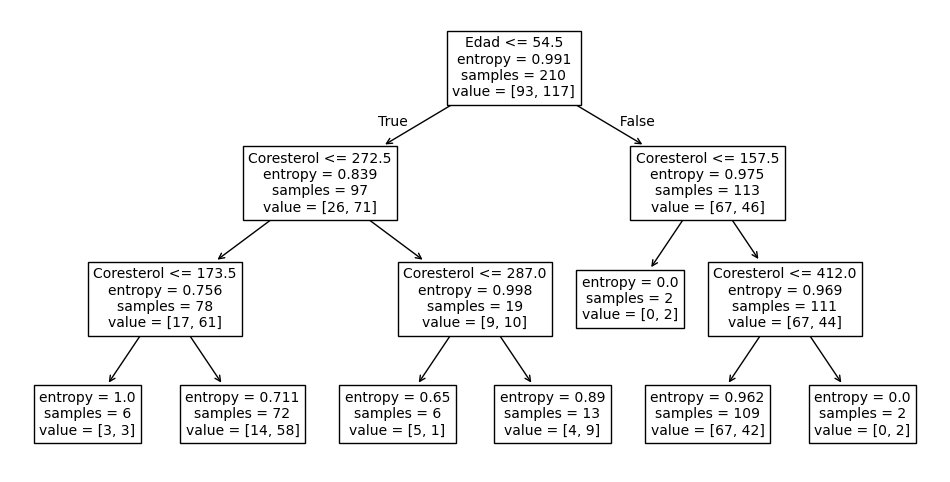

In [29]:
from sklearn import tree

# Instacionamos nuestro modelo
arbol_descision = tree.DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3
)

# Entrenamos nuestor modelo
arbol = arbol_descision.fit(datos_entrena, clase_entrena)

# Probamos la efectividad
accuracy = arbol_descision.score(datos_prueba, clase_prueba)
print(accuracy)

# También lo imprimmos pero en texto
print(tree.export_text(arbol,
                      feature_names=["Edad", "Coresterol"]))

plt.figure(figsize=(12,6))

# Imprimos nuestro arbol visual
tree.plot_tree(arbol, 
              feature_names=["Edad", "Coresterol"])

plt.show()

### Clasifica a nuevos pacientes.

In [30]:
print("Nuevo Paciente", arbol_descision.predict([[70,150]]))

Nuevo Paciente [1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
